In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set up matplotlib for inline plotting
%matplotlib inline

In [3]:
# Dataset 1: Sales data over time
np.random.seed(42)
dates = pd.date_range('2023-01-01', periods=12, freq='M')
sales_data = pd.DataFrame({
    'date': dates,
    'sales': [100, 120, 140, 160, 180, 200, 190, 210, 230, 250, 240, 280],
    'profit': [20, 25, 30, 35, 40, 45, 42, 48, 52, 58, 55, 65]
})

# Dataset 2: Student performance data
subjects = ['Math', 'Science', 'English', 'History', 'Art']
scores_2022 = [85, 78, 92, 88, 75]
scores_2023 = [88, 82, 94, 85, 80]

performance_data = pd.DataFrame({
    'subject': subjects,
    'scores_2022': scores_2022,
    'scores_2023': scores_2023
})

# Dataset 3: Temperature data with outliers
np.random.seed(123)
temperature_data = pd.DataFrame({
    'day': range(1, 31),
    'temperature': np.random.normal(25, 5, 30)
})
# Add some outliers
temperature_data.loc[10, 'temperature'] = 40  # Hot day
temperature_data.loc[20, 'temperature'] = 5   # Cold day

print("Sample datasets created successfully!")
print("\nSales data preview:")
print(sales_data.head())

Sample datasets created successfully!

Sales data preview:
        date  sales  profit
0 2023-01-31    100      20
1 2023-02-28    120      25
2 2023-03-31    140      30
3 2023-04-30    160      35
4 2023-05-31    180      40


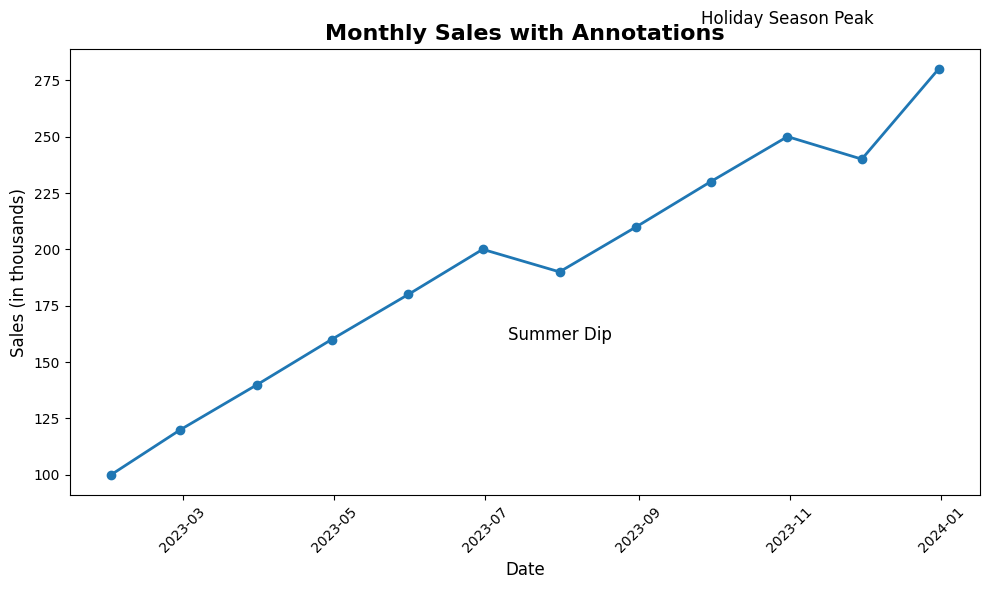

In [4]:
# Create a basic plot with text annotations
plt.figure(figsize=(10, 6))
plt.plot(sales_data['date'], sales_data['sales'], marker='o', linewidth=2, markersize=6)

# Add text annotations for specific points
plt.annotate('Holiday Season Peak', 
             xy=(sales_data['date'].iloc[-1], sales_data['sales'].iloc[-1]),
             xytext=(sales_data['date'].iloc[-3], sales_data['sales'].iloc[-1] + 20),
             fontsize=12,
             ha='center')

plt.annotate('Summer Dip', 
             xy=(sales_data['date'].iloc[6], sales_data['sales'].iloc[6]),
             xytext=(sales_data['date'].iloc[6], sales_data['sales'].iloc[6] - 30),
             fontsize=12,
             ha='center')

plt.title('Monthly Sales with Annotations', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales (in thousands)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

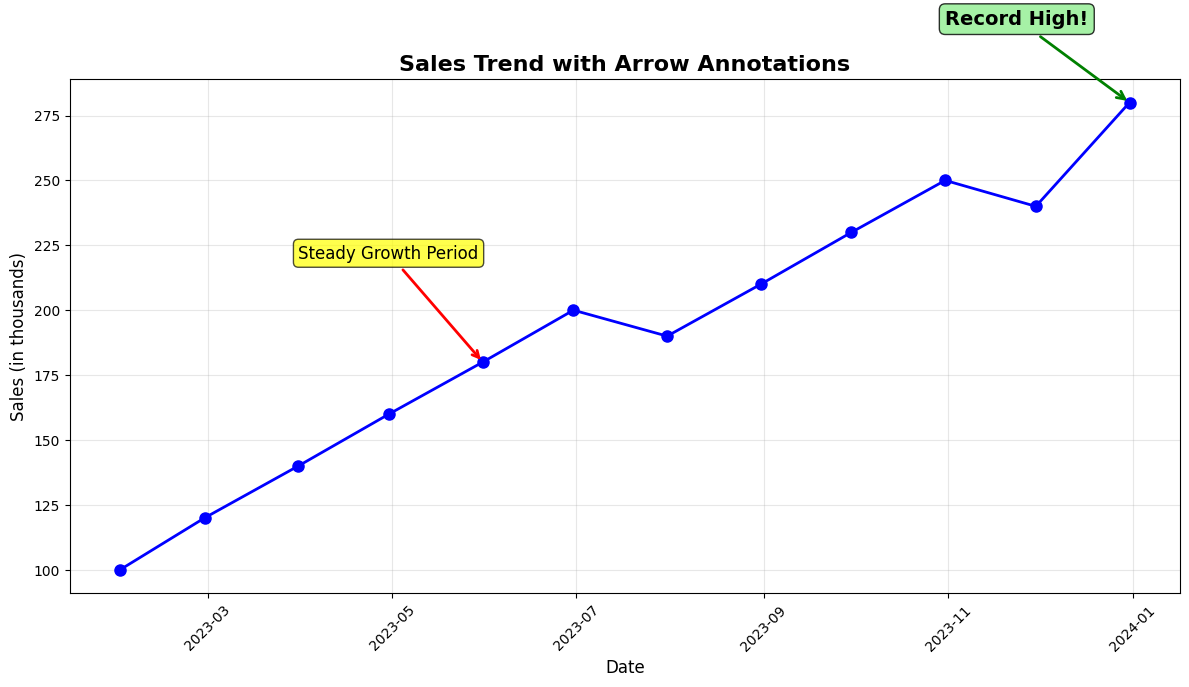

In [5]:
# Create a plot with arrow annotations
plt.figure(figsize=(12, 7))
plt.plot(sales_data['date'], sales_data['sales'], marker='o', linewidth=2, markersize=8, color='blue')

# Add arrow annotations
plt.annotate('Steady Growth Period', 
             xy=(sales_data['date'].iloc[4], sales_data['sales'].iloc[4]),
             xytext=(sales_data['date'].iloc[2], sales_data['sales'].iloc[4] + 40),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.annotate('Record High!', 
             xy=(sales_data['date'].iloc[-1], sales_data['sales'].iloc[-1]),
             xytext=(sales_data['date'].iloc[-3], sales_data['sales'].iloc[-1] + 30),
             arrowprops=dict(arrowstyle='->', color='green', lw=2),
             fontsize=14,
             fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.8))

plt.title('Sales Trend with Arrow Annotations', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales (in thousands)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

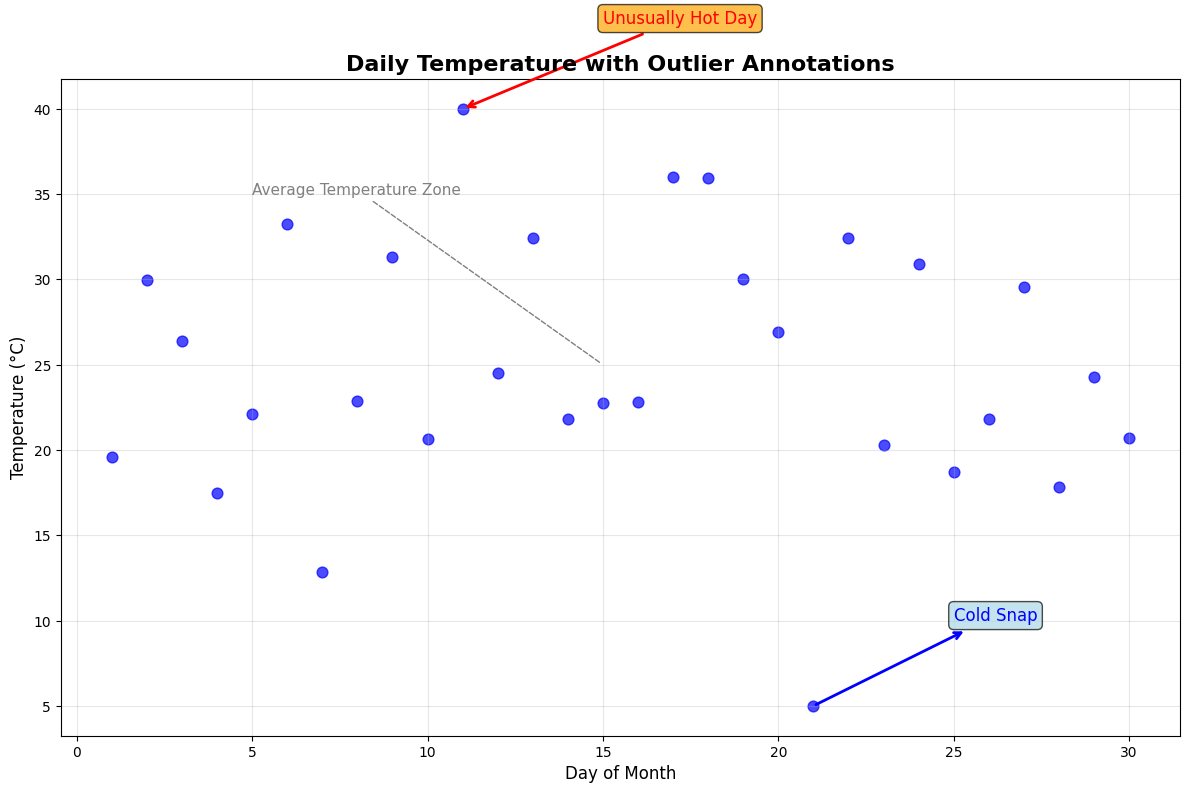

In [6]:
# Create a scatter plot with various annotation styles
plt.figure(figsize=(12, 8))
plt.scatter(temperature_data['day'], temperature_data['temperature'], 
           s=60, alpha=0.7, c='blue')

# Highlight outliers with different annotation styles
# Hot day annotation
plt.annotate('Unusually Hot Day', 
             xy=(11, 40),
             xytext=(15, 45),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=12,
             color='red',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="orange", alpha=0.7))

# Cold day annotation
plt.annotate('Cold Snap', 
             xy=(21, 5),
             xytext=(25, 10),
             arrowprops=dict(arrowstyle='<-', color='blue', lw=2),
             fontsize=12,
             color='blue',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

# Add a general trend annotation
plt.annotate('Average Temperature Zone', 
             xy=(15, 25),
             xytext=(5, 35),
             arrowprops=dict(arrowstyle='-', color='gray', lw=1, linestyle='--'),
             fontsize=11,
             color='gray')

plt.title('Daily Temperature with Outlier Annotations', fontsize=16, fontweight='bold')
plt.xlabel('Day of Month', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

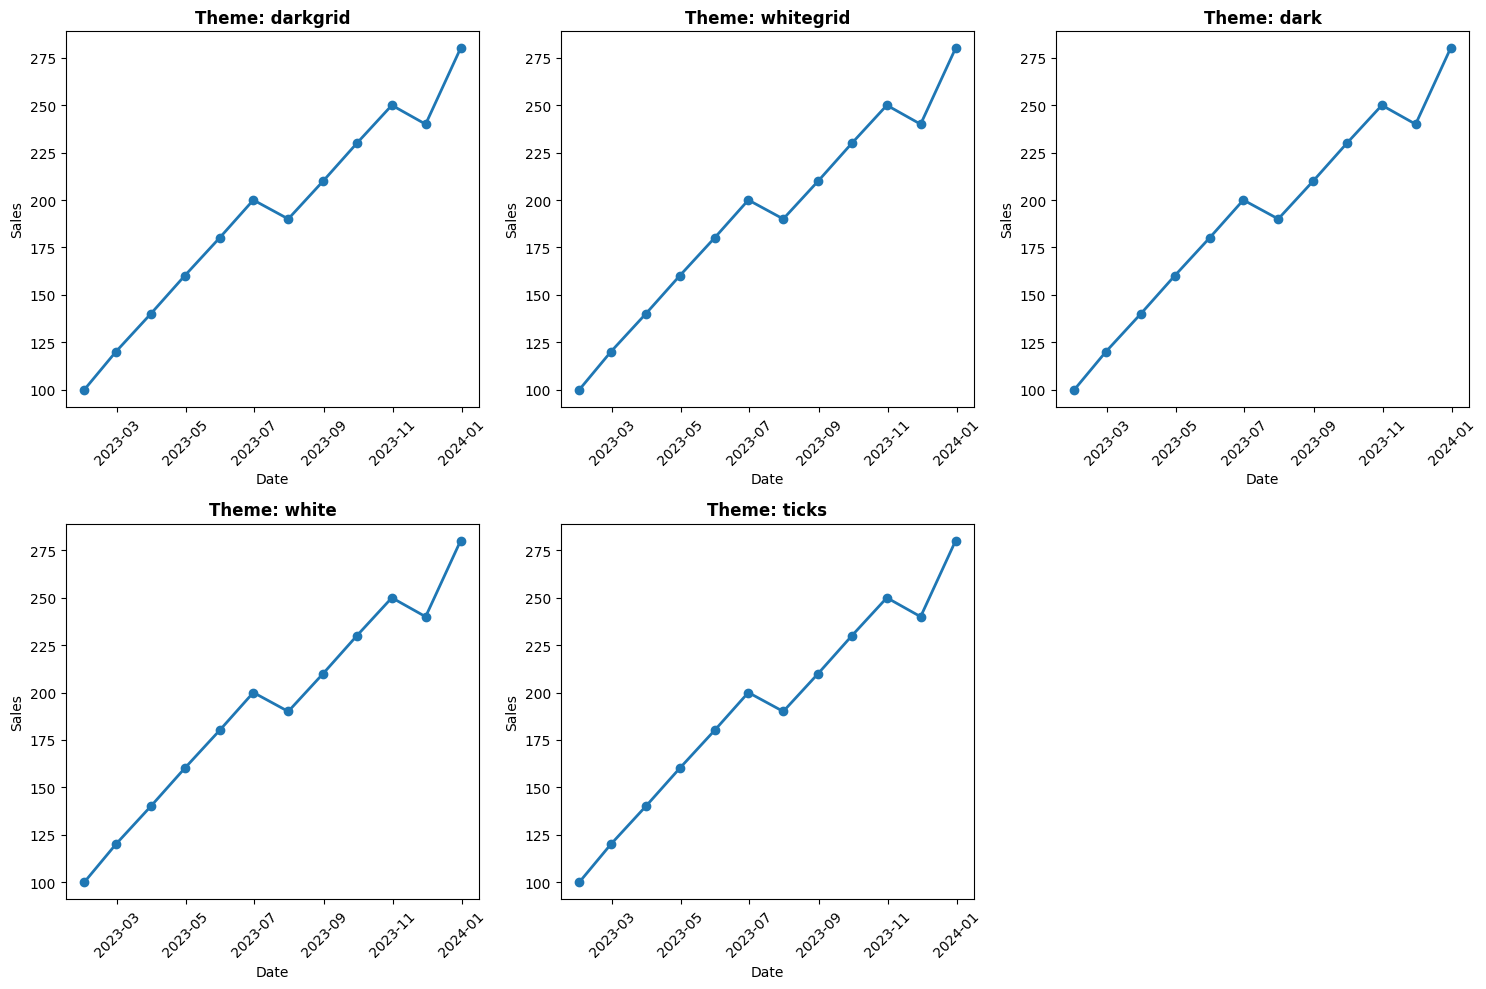

In [7]:
# Available seaborn themes
themes = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']

# Create subplots to compare themes
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, theme in enumerate(themes):
    sns.set_style(theme)
    ax = axes[i]
    
    # Create the same plot with different themes
    ax.plot(sales_data['date'], sales_data['sales'], marker='o', linewidth=2)
    ax.set_title(f'Theme: {theme}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Sales')
    
    # Rotate x-axis labels
    for label in ax.get_xticklabels():
        label.set_rotation(45)

# Remove the empty subplot
axes[-1].remove()

plt.tight_layout()
plt.show()

# Reset to default theme
sns.set_style('whitegrid')

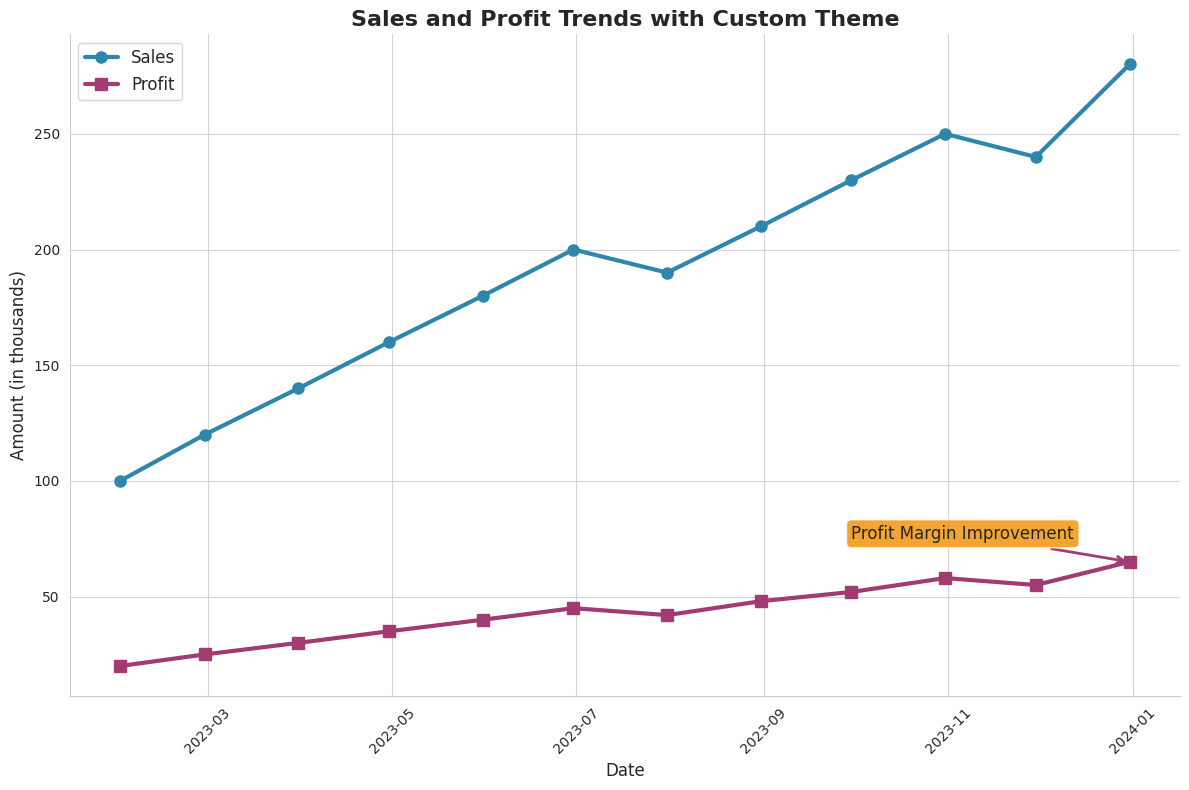

In [8]:
# Set a custom theme with specific parameters
sns.set_style("whitegrid", {
    "axes.spines.left": True,
    "axes.spines.bottom": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.linewidth": 0.5,
    "grid.color": "lightgray"
})

# Create a customized plot
plt.figure(figsize=(12, 8))

# Plot both sales and profit
plt.plot(sales_data['date'], sales_data['sales'], marker='o', linewidth=3, 
         label='Sales', color='#2E86AB', markersize=8)
plt.plot(sales_data['date'], sales_data['profit'], marker='s', linewidth=3, 
         label='Profit', color='#A23B72', markersize=8)

# Add annotations with custom styling
plt.annotate('Profit Margin Improvement', 
             xy=(sales_data['date'].iloc[-1], sales_data['profit'].iloc[-1]),
             xytext=(sales_data['date'].iloc[-4], sales_data['profit'].iloc[-1] + 10),
             arrowprops=dict(arrowstyle='->', color='#A23B72', lw=2),
             fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="#F18F01", alpha=0.8))

plt.title('Sales and Profit Trends with Custom Theme', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Amount (in thousands)', fontsize=12)
plt.legend(fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

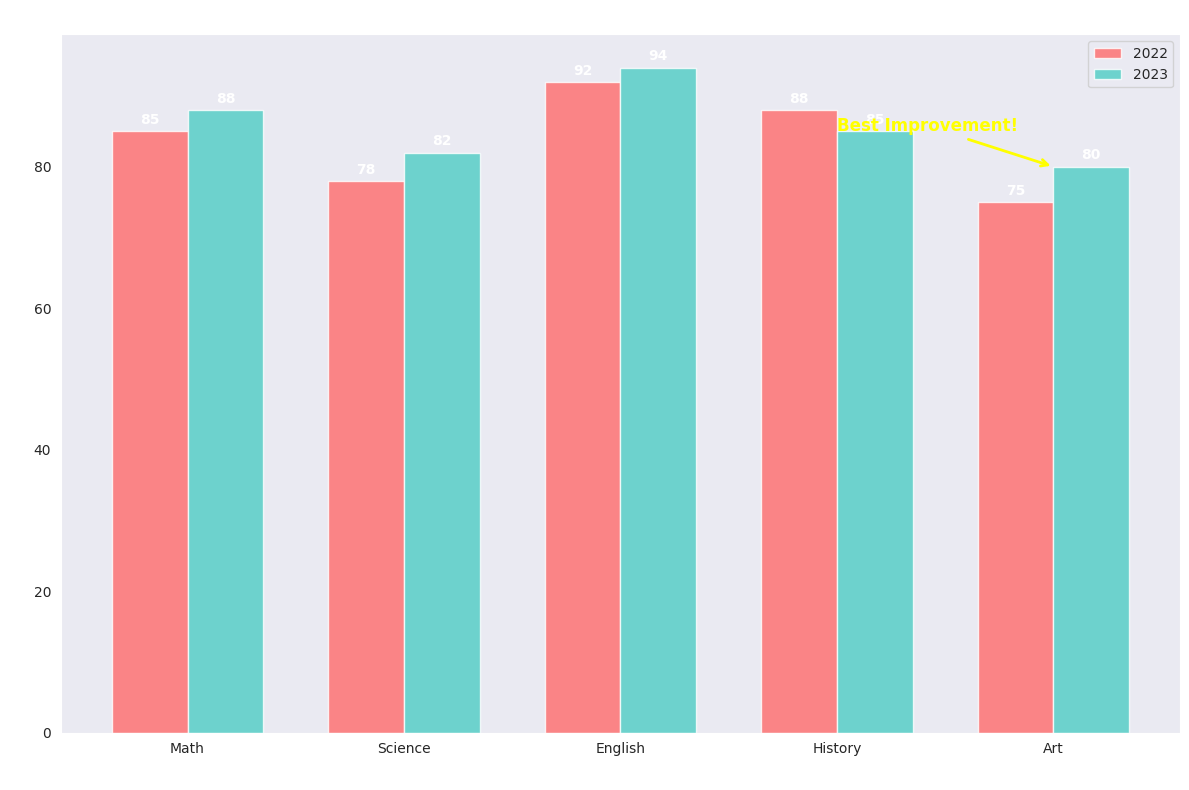

In [9]:
# Set dark theme
plt.style.use('dark_background')
sns.set_style("dark")

plt.figure(figsize=(12, 8))

# Create a bar plot with dark theme
x_pos = np.arange(len(performance_data['subject']))
width = 0.35

bars1 = plt.bar(x_pos - width/2, performance_data['scores_2022'], width, 
                label='2022', color='#FF6B6B', alpha=0.8)
bars2 = plt.bar(x_pos + width/2, performance_data['scores_2023'], width, 
                label='2023', color='#4ECDC4', alpha=0.8)

# Add value annotations on bars
for bar in bars1:
    height = bar.get_height()
    plt.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom',
                color='white', fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    plt.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom',
                color='white', fontweight='bold')

# Highlight the best improvement
plt.annotate('Best Improvement!', 
             xy=(4, 80),
             xytext=(3, 85),
             arrowprops=dict(arrowstyle='->', color='yellow', lw=2),
             fontsize=12,
             color='yellow',
             fontweight='bold')

plt.title('Student Performance Comparison (Dark Theme)', fontsize=16, 
          fontweight='bold', color='white')
plt.xlabel('Subjects', fontsize=12, color='white')
plt.ylabel('Scores', fontsize=12, color='white')
plt.xticks(x_pos, performance_data['subject'])
plt.legend()
plt.tight_layout()
plt.show()

# Reset to default style
plt.style.use('default')
sns.set_style('whitegrid')

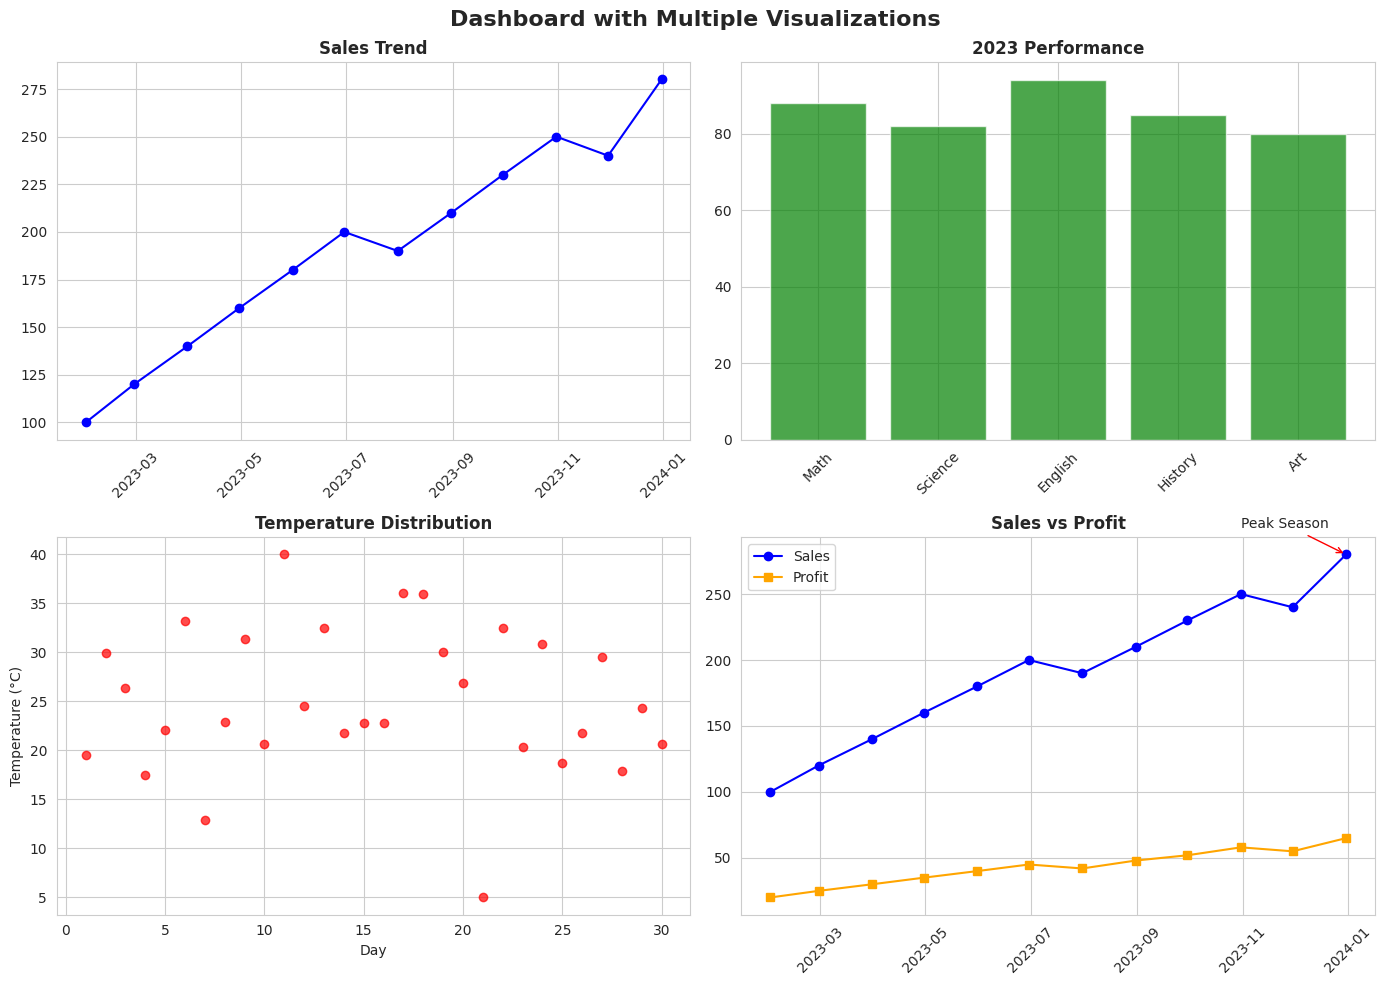

In [10]:
# Create multiple subplots with custom sizing
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Adjust spacing between subplots
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Plot 1: Line plot
axes[0, 0].plot(sales_data['date'], sales_data['sales'], marker='o', color='blue')
axes[0, 0].set_title('Sales Trend', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Bar plot
axes[0, 1].bar(performance_data['subject'], performance_data['scores_2023'], color='green', alpha=0.7)
axes[0, 1].set_title('2023 Performance', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)

# Plot 3: Scatter plot
axes[1, 0].scatter(temperature_data['day'], temperature_data['temperature'], alpha=0.7, color='red')
axes[1, 0].set_title('Temperature Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Temperature (°C)')

# Plot 4: Combined plot with annotations
axes[1, 1].plot(sales_data['date'], sales_data['sales'], marker='o', label='Sales', color='blue')
axes[1, 1].plot(sales_data['date'], sales_data['profit'], marker='s', label='Profit', color='orange')
axes[1, 1].annotate('Peak Season', 
                   xy=(sales_data['date'].iloc[-1], sales_data['sales'].iloc[-1]),
                   xytext=(sales_data['date'].iloc[-3], sales_data['sales'].iloc[-1] + 20),
                   arrowprops=dict(arrowstyle='->', color='red'))
axes[1, 1].set_title('Sales vs Profit', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Dashboard with Multiple Visualizations', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

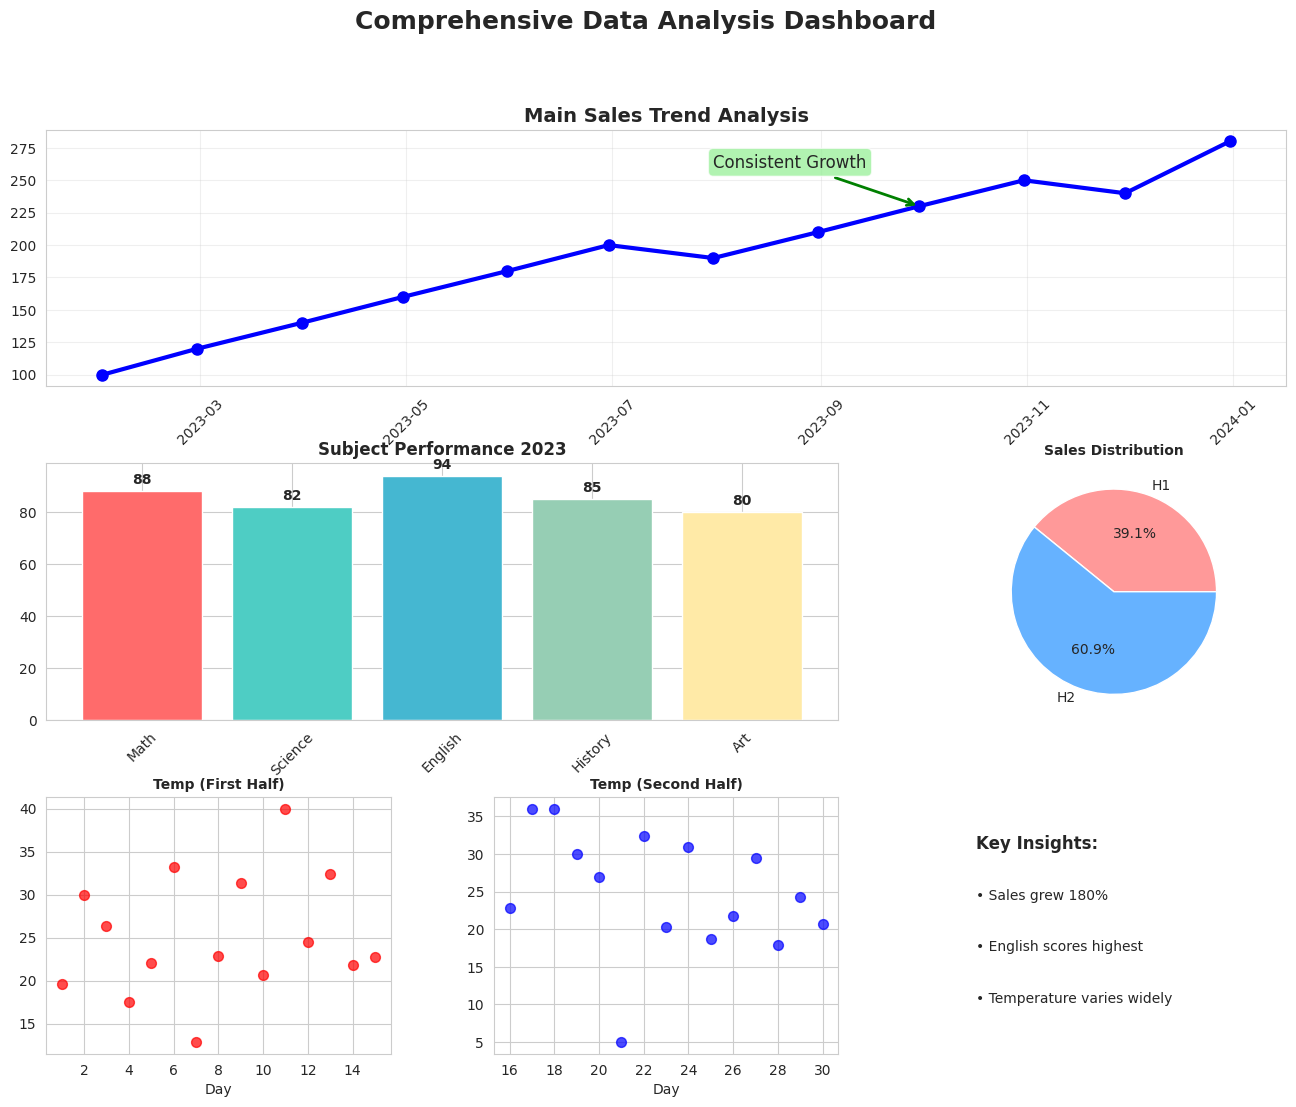

In [11]:
# Create a complex layout using GridSpec
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(16, 12))
gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)

# Large plot spanning multiple cells
ax1 = fig.add_subplot(gs[0, :])  # Top row, all columns
ax1.plot(sales_data['date'], sales_data['sales'], marker='o', linewidth=3, markersize=8, color='blue')
ax1.annotate('Consistent Growth', 
             xy=(sales_data['date'].iloc[8], sales_data['sales'].iloc[8]),
             xytext=(sales_data['date'].iloc[6], sales_data['sales'].iloc[8] + 30),
             arrowprops=dict(arrowstyle='->', color='green', lw=2),
             fontsize=12,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.7))
ax1.set_title('Main Sales Trend Analysis', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Medium plot
ax2 = fig.add_subplot(gs[1, :2])  # Second row, first two columns
bars = ax2.bar(performance_data['subject'], performance_data['scores_2023'], 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
ax2.set_title('Subject Performance 2023', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom',
                fontweight='bold')

# Small plot 1
ax3 = fig.add_subplot(gs[1, 2])  # Second row, third column
ax3.pie([sum(sales_data['sales'][:6]), sum(sales_data['sales'][6:])], 
        labels=['H1', 'H2'], autopct='%1.1f%%', colors=['#FF9999', '#66B2FF'])
ax3.set_title('Sales Distribution', fontsize=10, fontweight='bold')

# Small plot 2
ax4 = fig.add_subplot(gs[2, 0])  # Third row, first column
ax4.scatter(temperature_data['day'][:15], temperature_data['temperature'][:15], 
           alpha=0.7, color='red', s=50)
ax4.set_title('Temp (First Half)', fontsize=10, fontweight='bold')
ax4.set_xlabel('Day')

# Small plot 3
ax5 = fig.add_subplot(gs[2, 1])  # Third row, second column
ax5.scatter(temperature_data['day'][15:], temperature_data['temperature'][15:], 
           alpha=0.7, color='blue', s=50)
ax5.set_title('Temp (Second Half)', fontsize=10, fontweight='bold')
ax5.set_xlabel('Day')

# Text summary
ax6 = fig.add_subplot(gs[2, 2])  # Third row, third column
ax6.text(0.1, 0.8, 'Key Insights:', fontsize=12, fontweight='bold', transform=ax6.transAxes)
ax6.text(0.1, 0.6, '• Sales grew 180%', fontsize=10, transform=ax6.transAxes)
ax6.text(0.1, 0.4, '• English scores highest', fontsize=10, transform=ax6.transAxes)
ax6.text(0.1, 0.2, '• Temperature varies widely', fontsize=10, transform=ax6.transAxes)
ax6.set_xlim(0, 1)
ax6.set_ylim(0, 1)
ax6.axis('off')

plt.suptitle('Comprehensive Data Analysis Dashboard', fontsize=18, fontweight='bold')
plt.show()

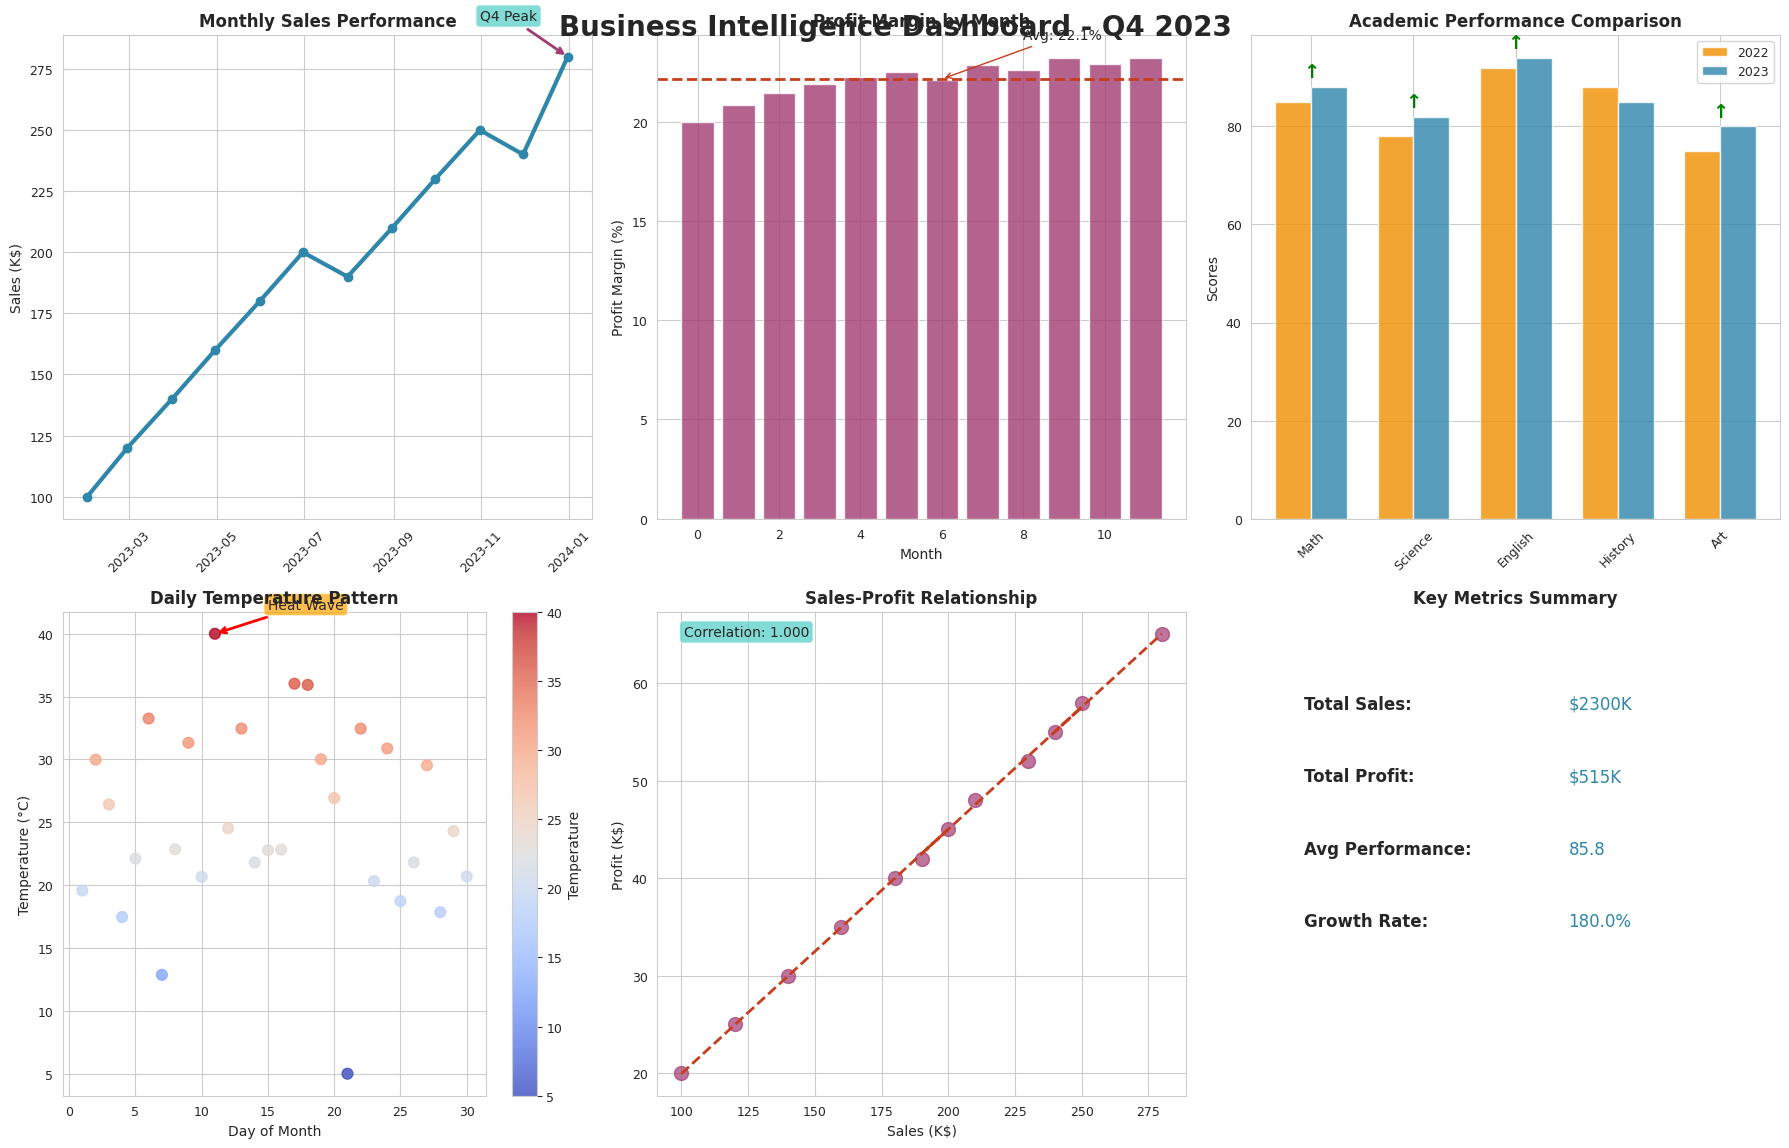

In [12]:
# Set a professional theme
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 16
})

# Create the professional dashboard
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Business Intelligence Dashboard - Q4 2023', fontsize=20, fontweight='bold', y=0.95)

# Color palette for consistency
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#4ECDC4']

# Plot 1: Sales trend with annotations
ax = axes[0, 0]
line = ax.plot(sales_data['date'], sales_data['sales'], marker='o', linewidth=3, 
               markersize=6, color=colors[0])
ax.annotate('Q4 Peak', 
           xy=(sales_data['date'].iloc[-1], sales_data['sales'].iloc[-1]),
           xytext=(sales_data['date'].iloc[-3], sales_data['sales'].iloc[-1] + 15),
           arrowprops=dict(arrowstyle='->', color=colors[1], lw=2),
           fontsize=10,
           bbox=dict(boxstyle="round,pad=0.3", facecolor=colors[4], alpha=0.7))
ax.set_title('Monthly Sales Performance', fontweight='bold')
ax.set_ylabel('Sales (K$)')
ax.tick_params(axis='x', rotation=45)

# Plot 2: Profit margin analysis
ax = axes[0, 1]
profit_margin = (sales_data['profit'] / sales_data['sales']) * 100
bars = ax.bar(range(len(profit_margin)), profit_margin, color=colors[1], alpha=0.8)
ax.axhline(y=profit_margin.mean(), color=colors[3], linestyle='--', linewidth=2)
ax.annotate(f'Avg: {profit_margin.mean():.1f}%', 
           xy=(6, profit_margin.mean()),
           xytext=(8, profit_margin.mean() + 2),
           arrowprops=dict(arrowstyle='->', color=colors[3]),
           fontsize=10)
ax.set_title('Profit Margin by Month', fontweight='bold')
ax.set_ylabel('Profit Margin (%)')
ax.set_xlabel('Month')

# Plot 3: Performance comparison
ax = axes[0, 2]
x = np.arange(len(performance_data['subject']))
width = 0.35
bars1 = ax.bar(x - width/2, performance_data['scores_2022'], width, 
               label='2022', color=colors[2], alpha=0.8)
bars2 = ax.bar(x + width/2, performance_data['scores_2023'], width, 
               label='2023', color=colors[0], alpha=0.8)

# Highlight improvements
for i, (score_2022, score_2023) in enumerate(zip(performance_data['scores_2022'], 
                                                 performance_data['scores_2023'])):
    if score_2023 > score_2022:
        ax.annotate('↑', xy=(i, max(score_2022, score_2023) + 2), 
                   ha='center', fontsize=14, color='green', fontweight='bold')

ax.set_title('Academic Performance Comparison', fontweight='bold')
ax.set_ylabel('Scores')
ax.set_xticks(x)
ax.set_xticklabels(performance_data['subject'], rotation=45)
ax.legend()

# Plot 4: Temperature distribution
ax = axes[1, 0]
scatter = ax.scatter(temperature_data['day'], temperature_data['temperature'], 
                    c=temperature_data['temperature'], cmap='coolwarm', s=60, alpha=0.8)
ax.annotate('Heat Wave', 
           xy=(11, 40),
           xytext=(15, 42),
           arrowprops=dict(arrowstyle='->', color='red', lw=2),
           fontsize=10,
           bbox=dict(boxstyle="round,pad=0.3", facecolor="orange", alpha=0.7))
ax.set_title('Daily Temperature Pattern', fontweight='bold')
ax.set_xlabel('Day of Month')
ax.set_ylabel('Temperature (°C)')
plt.colorbar(scatter, ax=ax, label='Temperature')

# Plot 5: Sales vs Profit correlation
ax = axes[1, 1]
ax.scatter(sales_data['sales'], sales_data['profit'], s=100, alpha=0.7, color=colors[1])
z = np.polyfit(sales_data['sales'], sales_data['profit'], 1)
p = np.poly1d(z)
ax.plot(sales_data['sales'], p(sales_data['sales']), "--", color=colors[3], linewidth=2)
correlation = np.corrcoef(sales_data['sales'], sales_data['profit'])[0, 1]
ax.annotate(f'Correlation: {correlation:.3f}', 
           xy=(0.05, 0.95), xycoords='axes fraction',
           bbox=dict(boxstyle="round,pad=0.3", facecolor=colors[4], alpha=0.7),
           fontsize=10)
ax.set_title('Sales-Profit Relationship', fontweight='bold')
ax.set_xlabel('Sales (K$)')
ax.set_ylabel('Profit (K$)')

# Plot 6: Summary metrics
ax = axes[1, 2]
metrics = {
    'Total Sales': f"${sum(sales_data['sales'])}K",
    'Total Profit': f"${sum(sales_data['profit'])}K",
    'Avg Performance': f"{performance_data['scores_2023'].mean():.1f}",
    'Growth Rate': f"{((sales_data['sales'].iloc[-1] / sales_data['sales'].iloc[0]) - 1) * 100:.1f}%"
}

y_pos = 0.8
for metric, value in metrics.items():
    ax.text(0.1, y_pos, f'{metric}:', fontsize=12, fontweight='bold', transform=ax.transAxes)
    ax.text(0.6, y_pos, value, fontsize=12, color=colors[0], transform=ax.transAxes)
    y_pos -= 0.15

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Key Metrics Summary', fontweight='bold')

plt.tight_layout()
plt.show()